In [14]:
# ---------------------------------------------------
# Heart Disease Dataset
# Data Cleaning, Transformation,
# Regression and kNN Model
# ---------------------------------------------------

# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [15]:
df = pd.read_csv("Cleavland.csv", header=None);
print(df.head());

     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0


In [16]:
# ---------------------------------------------------
# a. DATA CLEANING
# ---------------------------------------------------
# Check missing values
print("\nMissing Values")
print(df.isnull().sum())

# Replace ? with NaN
df.replace('?', np.nan, inplace=True)

# Remove NA values
df.dropna(inplace=True)

# Covert to numeric
df = df.apply(pd.to_numeric)

or 

for col in df.columns:
    df[col] = pd.to_numeric(df[col])

# Remove negative values
numeric_cols = df.columns

for col in numeric_cols:
    df = df[df[col] >= 0]

    or

df = df[(df[numeric_cols] >= 0).all(axis=1)]

print("\nDataset after cleaning")
print(df.head())



Missing Values
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64

Dataset after cleaning
     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0


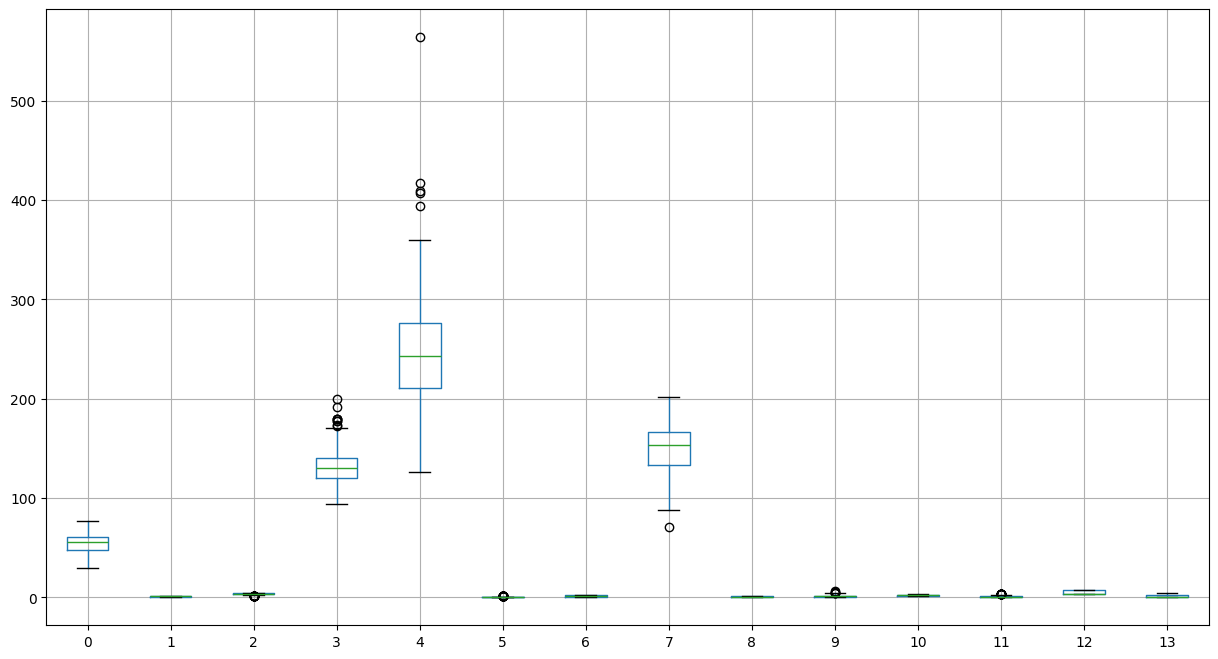

In [17]:
plt.figure(figsize=(15,8))
df.boxplot()
plt.show()

In [18]:
# ---------------------------------------------------
# b. OUTLIER DETECTION AND REMOVAL
# Using IQR Method
# ---------------------------------------------------

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lowerlimit = Q1 - 1.5 * IQR
upperlimit = Q3 + 1.5 * IQR

df = df[~((df < lowerlimit) | (df > upperlimit)).any(axis=1)]

print("\nDataset after outlier removal")
print(df.shape)


Dataset after outlier removal
(212, 14)


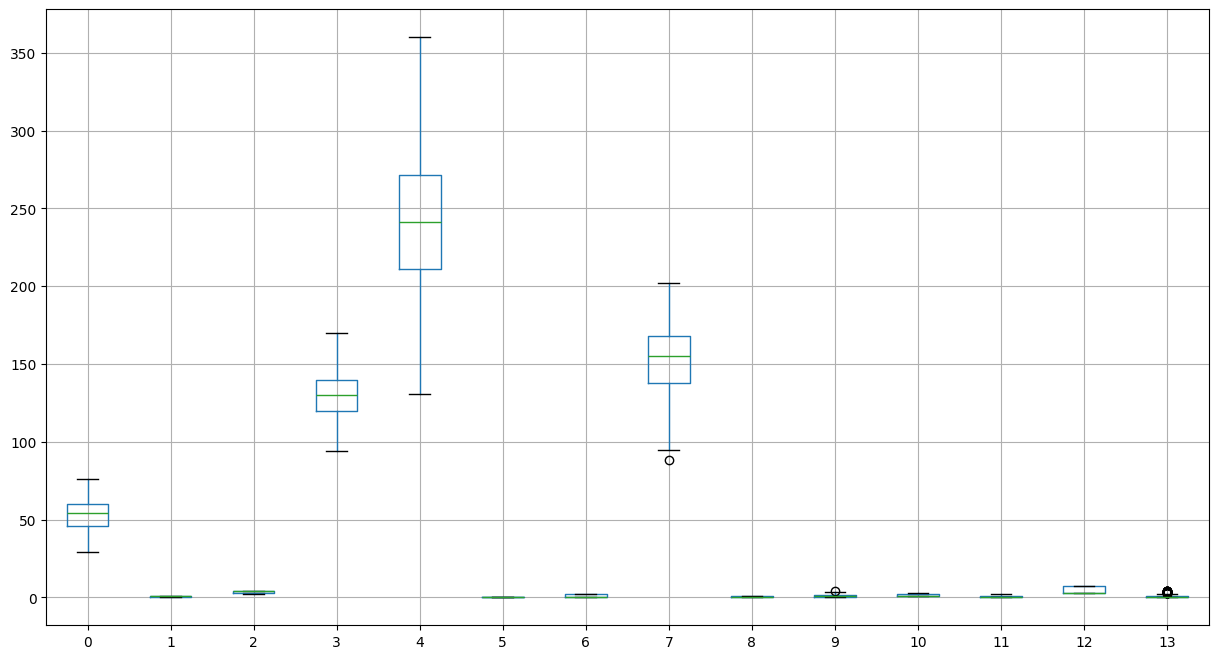

In [19]:
plt.figure(figsize=(15,8))
df.boxplot()
plt.show()

In [26]:
# ---------------------------------------------------
# c. DATA TRANSFORMATION
# ---------------------------------------------------

# Input and Output
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Convert target to binary
# 0 = No Disease
# 1 = Disease
y = np.where(y > 0, 1, 0)

# Feature Scaling
scaler = StandardScaler()

X = scaler.fit_transform(X)

print("\nData Transformation Completed")


Data Transformation Completed


In [27]:
# ---------------------------------------------------
# d. BUILD DATA MODELS
# ---------------------------------------------------

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [28]:
# ---------------------------------------------------
# 1. Logistic Regression Model
# ---------------------------------------------------

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("\nLogistic Regression Accuracy:")
print(lr_accuracy * 100)



Logistic Regression Accuracy:
72.09302325581395


In [29]:
# ---------------------------------------------------
# 2. kNN Model
# ---------------------------------------------------

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("\nkNN Accuracy:")
print(knn_accuracy * 100)


kNN Accuracy:
69.76744186046511


In [30]:
# ---------------------------------------------------
# Accuracy Comparison
# ---------------------------------------------------

print("\nAccuracy Comparison")

if lr_accuracy > knn_accuracy:
    print("Logistic Regression gives better accuracy")
elif knn_accuracy > lr_accuracy:
    print("kNN gives better accuracy")
else:
    print("Both models give same accuracy")


Accuracy Comparison
Logistic Regression gives better accuracy
